# 17.2 Multivariate Poisson Cokriging with PyGStat


**Dataset:** Simulated co-regionalised disease counts (217 units) + US Northeast county diabetes (`data/diabetes_northeast.shp` / `.csv`, 217 counties)
**Target:** Latent disease risk $R_t$ — HIV-like rare counts in the simulation; diagnosed diabetes (`Diabetes_count` / `POP_Total`) in the application, with physical inactivity and obesity as auxiliaries
**Library:** `pygstat.multi_poisson_kriging` — Linear Model of Coregionalization (LMC) Poisson cokriging (Payares-Garcia et al., 2024)


***
## Table of Contents

1. [Overview](#1-overview)
2. [Theory - Poisson Data Model](#2-theory--poisson-data-model)
3. [Theory - Population-Weighted Semivariograms](#3-theory--population-weighted-semivariograms)
4. [Theory - Linear Model of Coregionalization](#4-theory--linear-model-of-coregionalization)
5. [Theory - The Poisson Cokriging System](#5-theory--the-poisson-cokriging-system)
6. [Theory - Prediction Error Variance](#6-theory--prediction-error-variance)
7. [Python Setup](#7-python-setup)
8. [Simulate a Multivariate Dataset](#8-simulate-a-multivariate-dataset)
9. [Simulated Risk Surfaces](#9-simulated-risk-surfaces)
10. [Empirical Direct and Cross Semivariograms](#10-empirical-direct-and-cross-semivariograms)
11. [Fit the Linear Model of Coregionalization](#11-fit-the-linear-model-of-coregionalization)
12. [Prediction: Cokriging vs Univariate Kriging](#12-prediction-cokriging-vs-univariate-kriging)
13. [Spatial View of Reconstructed Target Risk](#13-spatial-view-of-reconstructed-target-risk)
14. [Leave-One-Out Smoothing](#14-leave-one-out-smoothing)
15. [Application: Diabetes in the US Northeast](#15-application-diabetes-in-the-us-northeast)
16. [Diabetes and Its Risk Factors](#16-diabetes-and-its-risk-factors)
17. [Northeast Semivariograms and LMC](#17-northeast-semivariograms-and-lmc)
18. [Predicting Held-Out Diabetes Rates](#18-predicting-held-out-diabetes-rates)
19. [Smoothed Diabetes Risk Map](#19-smoothed-diabetes-risk-map)
20. [CPU vs GPU Poisson Cokriging Timing](#20-cpu-vs-gpu-poisson-cokriging-timing)
21. [Summary and Conclusions](#21-summary-and-conclusions)
22. [Resources](#22-resources)


***
## 1. Overview

Mapping disease risk from areal counts is hampered by three things: counts are discrete and often over-dispersed; dividing counts by population gives heavy-tailed, unreliable *rates* (the small-number problem); and a single disease rarely carries enough signal on its own. **Multivariate Poisson cokriging** addresses all three by (i) treating each count as Poisson, (ii) modelling several spatially co-regionalised diseases jointly through a **Linear Model of Coregionalization (LMC)**, and (iii) predicting or smoothing a target disease's risk by borrowing strength from correlated auxiliary diseases.

`pygstat.multi_poisson_kriging` is a Python conversion of the R implementation of Payares-Garcia et al. (2024). This notebook develops the mathematics, validates it on a controlled simulation, and applies it to **diabetes in the US Northeast** using physical inactivity and obesity as auxiliaries.

| Step | What we do |
|---|---|
| Simulation | Draw 4 co-regionalised risk fields; Poisson counts on a shared population |
| Variograms | Population-weighted direct/cross $\hat\gamma_{\ell\kappa}(h)$ |
| LMC | Fit a valid coregionalization matrix $B\succeq 0$ |
| Prediction | Hold out 30% of the target; compare PK vs bi/tri/tetra-variate PCK |
| Application | Northeast diabetes, with inactivity and obesity as auxiliaries |
| CPU / GPU | Time k-NN `poisson_cokrige` on CPU vs GPU using **USA diabetes** counties (`usa_diabetes_data.csv` + `US_COUNTY.shp`, $n=3{,}107$) |

By the end you will have a validated LMC cokriging predictor, a Northeast diabetes map that borrows strength from inactivity and obesity, and a CPU vs GPU timing of the batched k-NN cokriging solve on the national county set.


***
## 2. Theory - Poisson Data Model

We follow Payares-Garcia et al. (2024). Let there be $\mathcal{L}$ diseases indexed by $\ell,\kappa\in\{1,\dots,\mathcal{L}\}$, observed over $N$ areal units with (population-weighted) centroids $s_1,\dots,s_N$. Unit $s_i$ has a population at risk $n(s_i)$ shared across diseases. Write $h=\lVert s_i-s_j\rVert$ and let $\varrho$ be the rate base (e.g. $\varrho=10^5$ for rates per 100,000).

Each count is conditionally Poisson given the latent **risk** $R_\ell$:

$$
Y_\ell(s_i)\,\big|\,R_\ell(s_i)\;\sim\;
\mathrm{Poisson}\!\big(n(s_i)\,R_\ell(s_i)\big),
\qquad
z_\ell(s_i)=\varrho\,\frac{Y_\ell(s_i)}{n(s_i)}.
$$

The sample rate $z_\ell$ is an unbiased but noisy estimator of $\varrho R_\ell$, and its sampling variance is inversely proportional to the population,

$$
\mathbb{E}[z_\ell(s_i)]=\varrho R_\ell(s_i),
\qquad
\mathrm{Var}[z_\ell(s_i)]\;\propto\;\frac{R_\ell(s_i)}{n(s_i)}.
$$

Small populations therefore give unreliable rates. The goal is to predict the target risk $R_t$ at an unsampled $s_0$, or to *smooth* it at observed units, filtering this Poisson noise.


***
## 3. Theory - Population-Weighted Semivariograms

Spatial dependence within and between diseases is measured with **population-weighted, bias-corrected** estimators (eqs. 12–13 of the paper). For pairs $(i,j)$ whose separation falls in lag class $N(h)$, and with the inverse-variance weights

$$
w_{ij}=\frac{n(s_i)\,n(s_j)}{n(s_i)+n(s_j)},
$$

the **direct** semivariogram of disease $\ell$ is

$$
\hat\gamma_{\ell\ell}(h)=\frac{1}{2\sum_{N(h)}w_{ij}}
\sum_{N(h)}\Big[\,w_{ij}\big(z_\ell(s_i)-z_\ell(s_j)\big)^2
-m^{*}_{\ell}\,\Big],
\qquad m^{*}_{\ell}=\varrho\,\frac{\sum_i Y_\ell(s_i)}{\sum_i n(s_i)},
$$

and the **cross** semivariogram between $\ell$ and $\kappa$ is

$$
\hat\gamma_{\ell\kappa}(h)=\frac{1}{2\sum_{N(h)}w_{ij}}
\sum_{N(h)}\Big[\,w_{ij}\big(z_\ell(s_i)-z_\ell(s_j)\big)
\big(z_\kappa(s_i)-z_\kappa(s_j)\big)-m_{\ell\kappa}\,\Big].
$$

The weights $w_{ij}$ homogenise the variance of the sample rates, while the **bias terms** $m^{*}_{\ell}$ and $m_{\ell\kappa}$ subtract the Poisson noise induced by population variability — without them the estimated sill is inflated by pure sampling noise. This is exactly what `pck_variogram` and `pck_crossvariogram` compute.


***
## 4. Theory - Linear Model of Coregionalization

To obtain a **valid** joint covariance for every pair of diseases, the direct and cross structures are fitted simultaneously with an LMC: a sum of $S$ basic, licit correlation structures $g_u$ (the paper uses a nested **exponential + spherical**; this module uses a single exponential, $S=1$),

$$
C_{\ell\kappa}(h)=\sum_{u=1}^{S} b^{u}_{\ell\kappa}\,g_u(h),
\qquad g_u(0)=1,
$$

with **coregionalization matrices** $B_u=\big[b^{u}_{\ell\kappa}\big]_{\mathcal L\times\mathcal L}$. The model is a valid multivariate covariance **iff every $B_u$ is symmetric positive semidefinite**; `fit_lmc` estimates $B_u$ by weighted least squares and then projects it onto the nearest PSD matrix. Covariance and semivariogram are linked by $\gamma_{\ell\kappa}(h)=C_{\ell\kappa}(0)-C_{\ell\kappa}(h)$, and for a single structure the sill is $C_{\ell\kappa}(0)=b_{\ell\kappa}=B_{\ell\kappa}$. Basic structures used here:

$$
g^{\text{exp}}(h)=e^{-h/a},
\qquad
g^{\text{sph}}(h)=
\Big(1-\tfrac{3h}{2a}+\tfrac{h^{3}}{2a^{3}}\Big)\mathbf{1}_{\{h\le a\}}.
$$


***
## 5. Theory - The Poisson Cokriging System

The target risk at $s_0$ is a linear combination of **all** diseases' sample rates (eq. 7):

$$
\hat R_t(s_0)=\sum_{\ell=1}^{\mathcal L}\sum_{i=1}^{k_\ell}
\lambda_{\ell}(s_i)\,z_\ell(s_i),
$$

where $k_\ell$ is the number of $\ell$-observations used and $\lambda_\ell(s_i)$ are the cokriging weights (negative predictions are truncated at $0$). The **Poisson shared risk** that couples diseases $\ell$ and $\kappa$ is modelled, in the spirit of Kawamura's bivariate Poisson, as

$$
R_{\ell\kappa}(s_i)=\rho_{\ell\kappa}\sqrt{R_\ell(s_i)\,R_\kappa(s_i)},
\qquad m_{\ell\kappa}=\overline{R_{\ell\kappa}},
$$

with $\rho_{\ell\kappa}$ the Poisson correlation (`shared_risk`).

The weights minimise the prediction variance subject to unbiasedness. This yields a linear system of $\big(\sum_{\ell}k_\ell+\mathcal L\big)$ equations in the weights $\lambda_\ell(s_i)$ and $\mathcal L$ Lagrange multipliers $\mu_\ell$ (eq. 9): for every disease $\ell$ and observation $s_i$,

$$
\sum_{\kappa=1}^{\mathcal L}\sum_{j=1}^{k_\kappa}
\lambda_{\kappa}(s_j)\Big[\,C_{\ell\kappa}(s_i,s_j)
+\Delta_{\ell\kappa}(s_i,s_j)\,\Big]
+\mu_\ell \;=\; C_{t\ell}(s_i,s_0),
$$

subject to the **unbiasedness constraints**

$$
\sum_{i=1}^{k_t}\lambda_t(s_i)=1,
\qquad
\sum_{i=1}^{k_\ell}\lambda_\ell(s_i)=0\quad(\ell\neq t).
$$

The target disease's weights sum to one; each auxiliary's weights sum to zero. The **bias / reliability terms** $\Delta_{\ell\kappa}$, added to the block diagonal, encode $\mathrm{Var}[z]\propto 1/n$:

$$
\Delta_{\ell\ell}(s_i,s_i)=\frac{m^{*}_\ell}{n(s_i)},
\qquad
\Delta_{\ell\kappa}(s_i,s_i)=\frac{m_{\ell\kappa}}{n(s_i)}
\ (\ell\neq\kappa),
$$

and $\Delta=0$ off the diagonal / for non-co-located pairs. Assembling the blocks $C_{\ell\kappa}$ plus the constraint rows/columns gives the matrix that `poisson_cokrige` builds and inverts.


***
## 6. Theory - Prediction Error Variance

With $c_0$ the right-hand-side covariance vector and $\lambda$ the solved weights (including the target Lagrange multiplier $\mu_t$), the cokriging variance is (eqs. 10–11)

$$
\sigma^{2}_t(s_0)=C_{tt}(0)-\sum_{\ell=1}^{\mathcal L}\sum_{i=1}^{k_\ell}
\lambda_\ell(s_i)\,C_{t\ell}(s_i,s_0)-\mu_t
\;=\;B_{tt}-\lambda^{\!\top}c_0.
$$

Because auxiliaries add information, this variance is systematically **smaller** than the univariate Poisson-kriging variance.

**Special cases**

- **Univariate Poisson kriging** ($\mathcal L=1$): the system collapses to ordinary Poisson kriging with a single reliability term $m^{*}/n(s_i)$ (`poisson_krige`).
- **Smoothing (noise filtering):** taking the prediction locations to be the observed units and removing each in turn (leave-one-out) yields denoised risk estimates instead of interpolated ones.

| Equation | Quantity | Module implementation |
|---|---|---|
| §3 (12) | direct Poisson semivariogram $\hat\gamma_{\ell\ell}$ | `pck_variogram` |
| §3 (13) | cross Poisson semivariogram $\hat\gamma_{\ell\kappa}$ | `pck_crossvariogram` |
| §5 | shared risk $R_{\ell\kappa}=\rho_{\ell\kappa}\sqrt{R_\ell R_\kappa}$ | `shared_risk` |
| §4 | LMC $C_{\ell\kappa}(h)=\sum_u b^u_{\ell\kappa}g_u(h)$, $B_u\succeq 0$ | `fit_lmc`, `LMC`, `c_exp`, `c_sph` |
| §5–6 (7,9,10) | cokriging predictor, system, variance | `poisson_cokrige` |
| special case | univariate Poisson kriging | `poisson_krige` |


***
## 7. Python Setup

### 7.1 CPU and GPU

`poisson_cokrige` in **k-nearest-neighbor** mode (`number_of_neighbors=k`) solves a
local Poisson cokriging system at every prediction point. Every point has the same
neighbor count $k$ and $P$ co-located variables, so pygstat stacks the systems into
one `(n_{\mathrm{pred}}, P k + P, P k + P)` batched `xp.linalg.solve` — NumPy on CPU,
CuPy on GPU. Pass `use_gpu='auto'|True|False`.

| Argument / mode | What it controls |
|-----------------|------------------|
| `number_of_neighbors` | Local k-NN. Required for the batched GPU path. |
| `use_gpu` | Batched k-NN cokriging solve (NumPy or CuPy). |
| default (no `k`) | **Global** system over every known area; stays on **CPU**. |
| `smooth=True` | Leave-one-out of a single area; stays on **CPU**. |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in
`USE_GPU`. The simulation and Northeast maps in §8–19 use the global / LOO CPU path.
**§20** times the k-NN GPU path on **USA county diabetes** ($n = 3{,}107$, $P=3$).

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import pygstat
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from scipy.optimize import least_squares
from pygstat import multi_poisson_kriging as mpk

plt.rcParams.update({"figure.dpi":110, "font.size":10,
                     "axes.spines.top":False, "axes.spines.right":False})
RNG = np.random.default_rng(512)     # R used seed = 512
POP_RATE = 100_000
print("module functions:", ", ".join(mpk.__all__))
print("pygstat version:", pygstat.__version__)

from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

# ── Poisson cokriging k-NN batched solve: CPU / GPU dispatch (CuPy) ────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — poisson_cokrige k-NN batched solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


I0000 00:00:1788928014.375624  695539 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


module functions: c_exp, c_sph, covariance_model, shared_risk, eb_risk, pck_variogram, pck_crossvariogram, LMC, fit_lmc, poisson_cokrige, poisson_krige
pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — poisson_cokrige k-NN batched solve on GPU
use_gpu         : True


***
## 8. Simulate a Multivariate Dataset

Mirroring the paper's simulation: draw $P=4$ co-regionalised latent Gaussian risk fields on an irregular set of locations (via $\mathrm{Cov}=B\otimes\rho$), convert to per-100k risks, and draw Poisson counts on a shared population. The target is an **HIV-incidence-like** disease with very low counts (deliberately noisy — the case cokriging is designed to help).


In [2]:
N = 217
cent = RNG.uniform([0, 0], [600, 400], size=(N, 2))          # locations (km)
D = np.sqrt(((cent[:, None, :] - cent[None, :, :]) ** 2).sum(-1))
P = 4
names = ["HIV Inc.", "HIV Prev.", "Chlamydia", "Gonorrhea"]
target = 0

range_true = 180.0
Rho = np.exp(-D / range_true)
# PSD coregionalization matrix (strong positive cross-dependence)
Lb = np.array([[1.0,0,0,0],[0.8,0.6,0,0],[0.7,0.4,0.5,0],[0.6,0.3,0.4,0.5]])
B_true = Lb @ Lb.T

big = np.kron(B_true, Rho)
Z = (np.linalg.cholesky(big + 1e-8*np.eye(P*N)) @ RNG.standard_normal(P*N)).reshape(P, N)

pop = np.clip(np.round(np.exp(RNG.normal(10.5, 0.9, N))), 500, None)   # shared denom
baseline = np.array([15.0, 260.0, 400.0, 150.0])                       # per-100k
rates_true = baseline[:, None] * np.exp(Z - 0.5*np.diag(B_true)[:, None])
counts = RNG.poisson(pop[None, :] * rates_true / POP_RATE).astype(float)
rates_obs = counts / pop[None, :] * POP_RATE

print("mean counts / disease:", np.round(counts.mean(1), 1))
print("observed-rate corr with target:",
      np.round([np.corrcoef(rates_obs[0], rates_obs[k])[0,1] for k in range(P)], 2))

mean counts / disease: [  7.4 194.5 360.3 103.3]
observed-rate corr with target: [1.   0.44 0.34 0.38]


***
## 9. Simulated Risk Surfaces


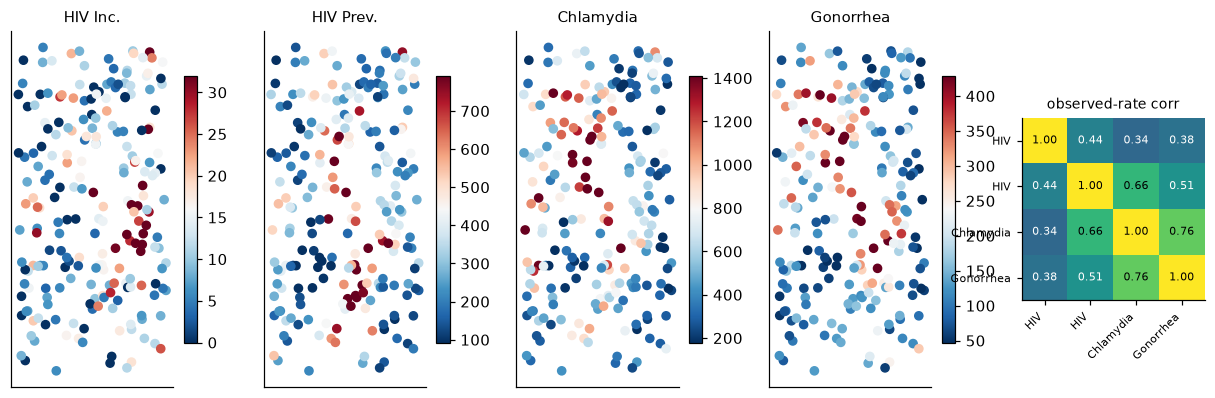

In [3]:
fig = plt.figure(figsize=(14, 4.2))
gs = GridSpec(1, 5, width_ratios=[1,1,1,1,0.9], wspace=0.25)
for l in range(P):
    ax = fig.add_subplot(gs[0, l])
    s = ax.scatter(cent[:,0], cent[:,1], c=rates_obs[l], s=28, cmap="RdBu_r",
                   vmin=np.percentile(rates_obs[l],5), vmax=np.percentile(rates_obs[l],95))
    ax.set_title(names[l], fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(s, ax=ax, shrink=.75)
axc = fig.add_subplot(gs[0, 4])
C = np.corrcoef(rates_obs)
im = axc.imshow(C, cmap="viridis", vmin=0, vmax=1)
axc.set_xticks(range(P)); axc.set_yticks(range(P))
axc.set_xticklabels([n.split()[0] for n in names], rotation=45, ha="right", fontsize=7)
axc.set_yticklabels([n.split()[0] for n in names], fontsize=7)
for i in range(P):
    for k in range(P):
        axc.text(k, i, f"{C[i,k]:.2f}", ha="center", va="center",
                 color="w" if C[i,k] < 0.6 else "k", fontsize=7)
axc.set_title("observed-rate corr", fontsize=9)
plt.tight_layout(); plt.show()

***
## 10. Empirical Direct and Cross Semivariograms

`pck_variogram` (direct) and `pck_crossvariogram` (cross) implement the population-weighted, Poisson-bias-corrected estimators. Shared risks $R_{lk}=\rho_{lk}\sqrt{R_l R_k}$ feed the cross-variogram bias term.


In [4]:
maxd = D.max() * 0.5
direct_vars = [mpk.pck_variogram(cent, counts[l], pop, POP_RATE, maxd, 12)
               for l in range(P)]
cross_pairs = [(l, k) for l in range(P) for k in range(l+1, P)]
rho_lk, shared_mean, cross_vars = {}, {}, []
for (l, k) in cross_pairs:
    rho = max(np.corrcoef(rates_obs[l], rates_obs[k])[0,1], 0.01)
    r = mpk.shared_risk(rates_obs[l], rates_obs[k], rho)
    rho_lk[(l,k)] = rho; shared_mean[(l,k)] = float(np.mean(r))
    cross_vars.append(mpk.pck_crossvariogram(cent, counts[l], counts[k], pop, r,
                                             POP_RATE, maxd, 12))

def fit_exp(lags, gam, npv):
    ok = np.isfinite(gam) & (gam >= 0); lags, gam, npv = lags[ok], gam[ok], npv[ok]
    s0 = gam.max()
    sol = least_squares(lambda p: (p[0]*(1-np.exp(-lags/p[1]))-gam)*np.sqrt(npv),
                        [s0, lags[len(lags)//2]], bounds=([0,lags.min()],[3*s0,lags.max()]))
    return float(sol.x[0]), float(sol.x[1])
range_common = fit_exp(*direct_vars[target])[1]
print(f"common range fit to target direct variogram: {range_common:.0f} km")

common range fit to target direct variogram: 31 km


***
## 11. Fit the Linear Model of Coregionalization

`fit_lmc` estimates each $B_{lk}$ by weighted least squares at the common range, then projects $B$ onto the nearest positive-semidefinite matrix (a valid LMC). The classic coregionalization display shows direct semivariograms on the diagonal and cross semivariograms off it, with the fitted LMC overlaid.


fitted LMC(model=Exp, range=30.8, P=4) 
coregionalization matrix B:
 [[1.030000e+02 1.041100e+03 1.440900e+03 5.535000e+02]
 [1.041100e+03 5.888060e+04 6.766560e+04 1.921750e+04]
 [1.440900e+03 6.766560e+04 1.618791e+05 4.624770e+04]
 [5.535000e+02 1.921750e+04 4.624770e+04 2.176590e+04]]


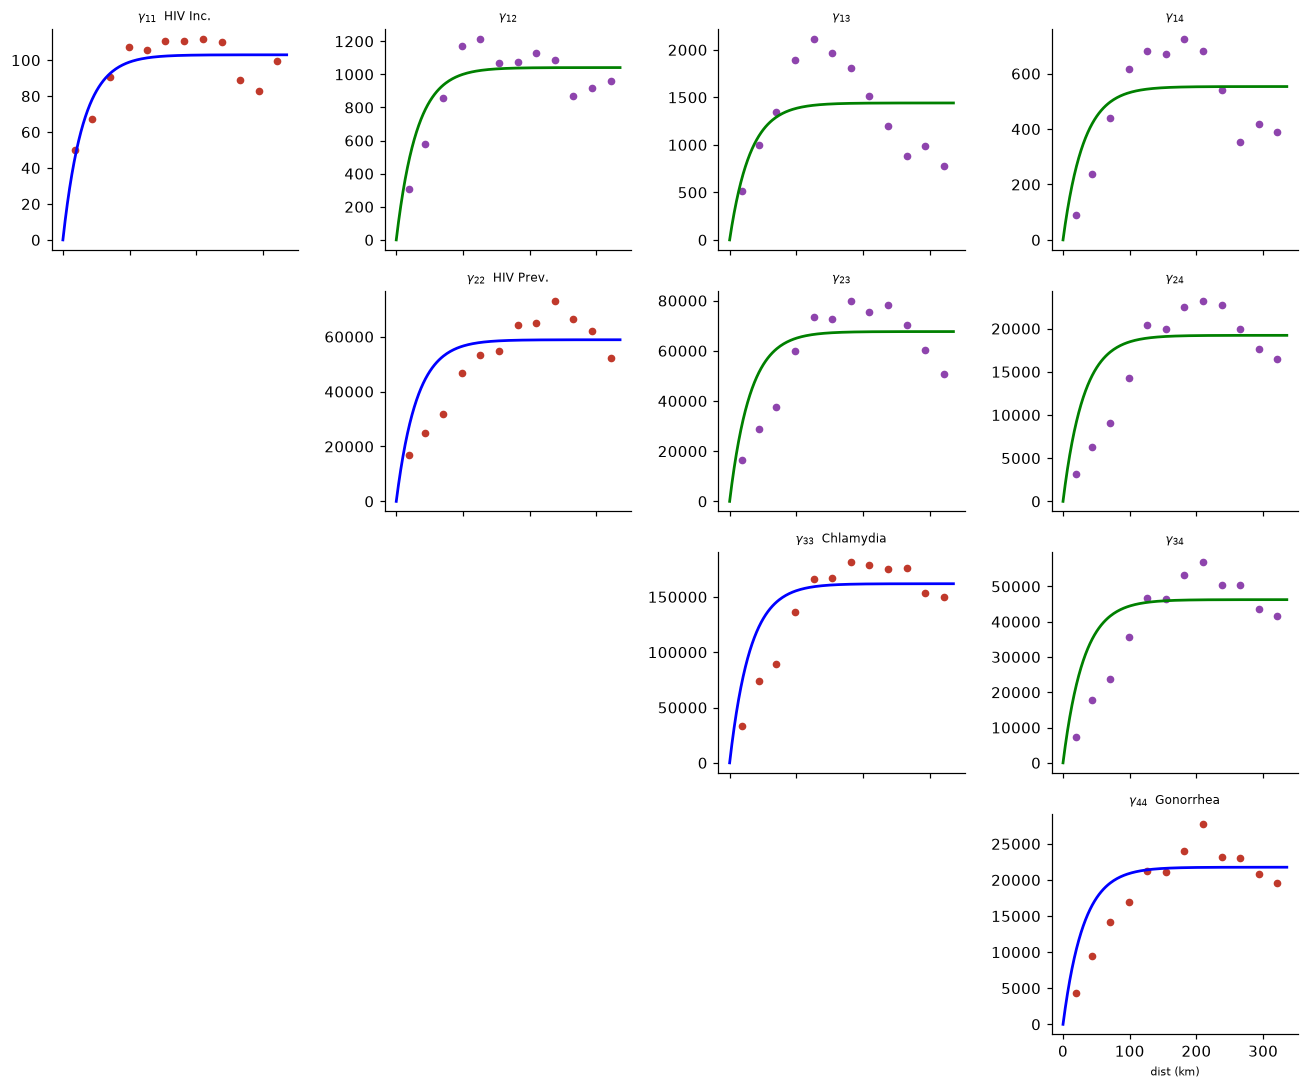

In [5]:
lmc = mpk.fit_lmc(direct_vars, cross_vars, cross_pairs, P,
                  rng=range_common, model="Exp", fit_range=False)
print("fitted", lmc, "\ncoregionalization matrix B:\n", np.round(lmc.B, 1))

fig, ax = plt.subplots(P, P, figsize=(12, 10), sharex=True)
hh = np.linspace(0, maxd, 200)
cross_lookup = {pair: cv for pair, cv in zip(cross_pairs, cross_vars)}
for l in range(P):
    for k in range(P):
        a = ax[l, k]
        if l == k:
            lags, gam, _ = direct_vars[l]
            a.plot(lags, gam, "o", ms=4, color="#c0392b")
            a.plot(hh, lmc.B[l,l]*(1-np.exp(-hh/lmc.range)), "b-", lw=1.8)
            a.set_title(f"$\\gamma_{{{l+1}{l+1}}}$  {names[l]}", fontsize=8)
        elif k > l:
            lags, gam, _ = cross_lookup[(l, k)]
            a.plot(lags, gam, "o", ms=4, color="#8e44ad")
            a.plot(hh, lmc.B[l,k]*(1-np.exp(-hh/lmc.range)), "g-", lw=1.8)
            a.set_title(f"$\\gamma_{{{l+1}{k+1}}}$", fontsize=8)
        else:
            a.axis("off")
        if l == P-1: a.set_xlabel("dist (km)", fontsize=7)
plt.tight_layout(); plt.show()

***
## 12. Prediction: Cokriging vs Univariate Kriging

Hold out 30% of the target's locations and predict them with univariate Poisson kriging (PK) and bi/tri/tetra-variate cokriging (PCK). Following the paper's **simulation** protocol, predictions are scored against the **known latent risk** (which filters out the irreducible Poisson noise that dominates a rare outcome like HIV incidence).


In [6]:
n_hold = int(0.30 * N)
hold = np.sort(RNG.choice(N, n_hold, replace=False))
mask = np.ones(N, bool); mask[hold] = False
coords_hold = cent[hold]
truth = rates_true[target][hold]           # known latent risk (simulation)

# univariate PK baseline, fit to the target's own direct variogram
sill_pk, range_pk = fit_exp(*mpk.pck_variogram(cent[mask], counts[target][mask],
                                               pop[mask], POP_RATE, maxd, 12))
pk = mpk.poisson_krige(dict(x=cent[mask,0], y=cent[mask,1],
                            cases=counts[target][mask], pop=pop[mask]),
                       sill=sill_pk, rng=range_pk, model="Exp",
                       pop_rate=POP_RATE, coords_pred=coords_hold)

def train_sets(variables):
    ds = []
    for l in variables:
        if l == target:
            ds.append(dict(x=cent[mask,0], y=cent[mask,1],
                           cases=counts[l][mask], pop=pop[mask]))
        else:
            ds.append(dict(x=cent[:,0], y=cent[:,1], cases=counts[l], pop=pop))
    return ds

def metrics(pred, label):
    e = pred - truth
    return dict(method=label, MSPE=np.mean(e**2), MAE=np.mean(np.abs(e)),
                cor=np.corrcoef(pred, truth)[0,1])

rows = [dict(**metrics(pk["pred"], "PK (univariate)"), mean_var=pk["var"].mean())]
preds = {"PK (univariate)": pk["pred"]}
for label, variables in [("PCK bivariate", [0,1]),
                         ("PCK trivariate", [0,1,2]),
                         ("PCK tetravariate", [0,1,2,3])]:
    sm = {}
    for a in range(len(variables)):
        for b in range(a+1, len(variables)):
            la, lb = variables[a], variables[b]
            sm[(a,b)] = shared_mean[(la,lb) if (la,lb) in shared_mean else (lb,la)]
    sub = mpk.LMC(lmc.B[np.ix_(variables, variables)], lmc.range, lmc.model)
    res = mpk.poisson_cokrige(train_sets(variables), 0, sub, POP_RATE, sm,
                              coords_pred=coords_hold)
    rows.append(dict(**metrics(res["pred"], label), mean_var=res["var"].mean()))
    preds[label] = res["pred"]

import pandas as pd
base = rows[0]["MSPE"]
tbl = pd.DataFrame(rows).set_index("method")
tbl["MSPE drop %"] = (100*(base - tbl["MSPE"])/base).round(0)
tbl.round(3)

,MSPE,MAE,cor,mean_var,MSPE drop %
method,,,,,
PK (univariate),42.095,4.409,0.796,55.179,0.0
PCK bivariate,30.403,3.609,0.862,51.195,28.0
PCK trivariate,30.414,3.646,0.862,50.765,28.0
PCK tetravariate,30.163,3.583,0.864,49.307,28.0


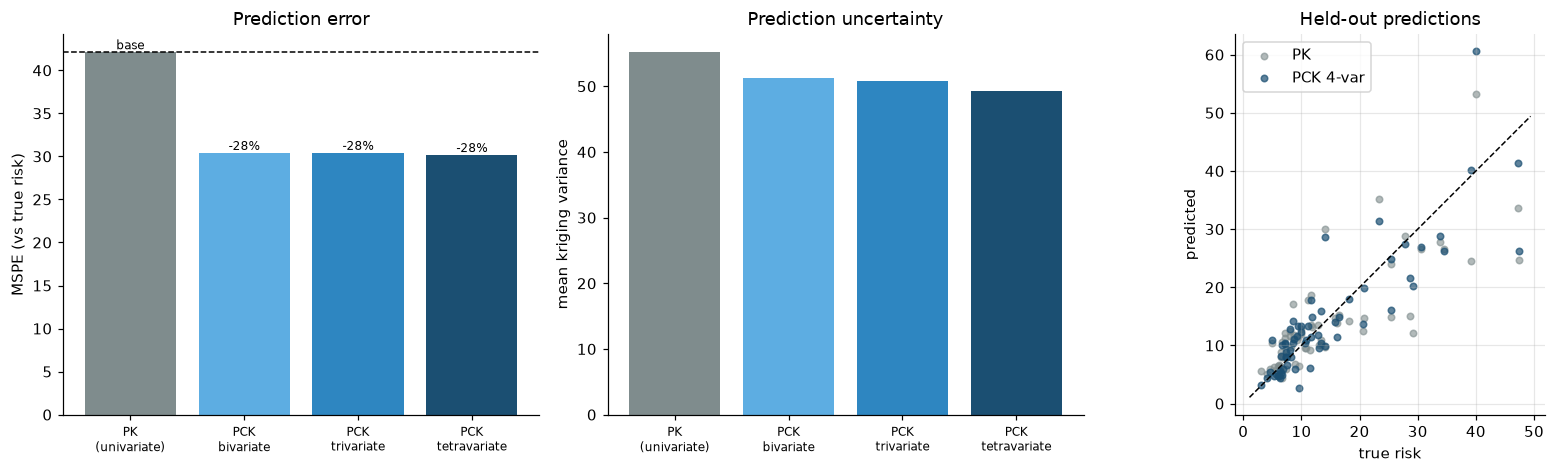

Best: PCK tetravariate -> MSPE reduced 28% vs univariate PK, correlation 0.80 -> 0.86 (paper: up to ~50% MSPE reduction in simulation).


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
labels = list(preds)
colors = ["#7f8c8d", "#5dade2", "#2e86c1", "#1b4f72"]
ax[0].bar(range(len(rows)), [r["MSPE"] for r in rows], color=colors)
ax[0].axhline(base, ls="--", c="k", lw=1)
ax[0].set_xticks(range(len(rows))); ax[0].set_xticklabels(
    [l.replace(" ", "\n") for l in labels], fontsize=8)
ax[0].set_ylabel("MSPE (vs true risk)"); ax[0].set_title("Prediction error")
for i, r in enumerate(rows):
    ax[0].text(i, r["MSPE"], f'-{100*(base-r["MSPE"])/base:.0f}%' if i else "base",
               ha="center", va="bottom", fontsize=8)

ax[1].bar(range(len(rows)), [r["mean_var"] for r in rows], color=colors)
ax[1].set_xticks(range(len(rows))); ax[1].set_xticklabels(
    [l.replace(" ", "\n") for l in labels], fontsize=8)
ax[1].set_ylabel("mean kriging variance"); ax[1].set_title("Prediction uncertainty")

lim = [truth.min()-2, truth.max()+2]
ax[2].plot(lim, lim, "k--", lw=1)
ax[2].scatter(truth, preds["PK (univariate)"], s=18, alpha=.6, label="PK", color="#7f8c8d")
ax[2].scatter(truth, preds["PCK tetravariate"], s=18, alpha=.7, label="PCK 4-var", color="#1b4f72")
ax[2].set_xlabel("true risk"); ax[2].set_ylabel("predicted"); ax[2].set_aspect("equal")
ax[2].set_title("Held-out predictions"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

best = min(rows[1:], key=lambda r: r["MSPE"])
print(f"Best: {best['method']} -> MSPE reduced {100*(base-best['MSPE'])/base:.0f}% "
      f"vs univariate PK, correlation {rows[0]['cor']:.2f} -> {best['cor']:.2f} "
      f"(paper: up to ~50% MSPE reduction in simulation).")

***
## 13. Spatial View of Reconstructed Target Risk

Training locations show the observed (noisy) rate; held-out locations show the tetravariate cokriging prediction. The cokriged field recovers the smooth latent structure the single-disease rates obscure.


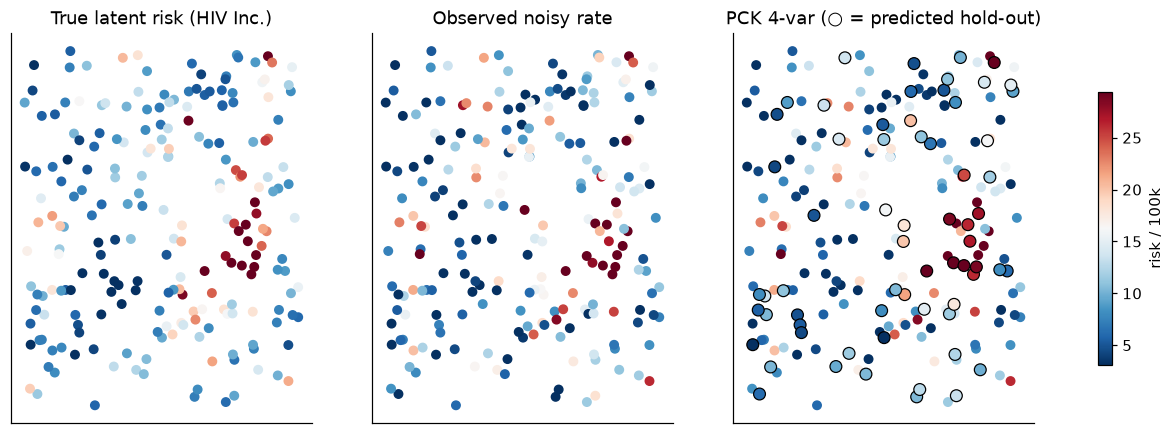

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
vmin, vmax = np.percentile(rates_true[target], 5), np.percentile(rates_true[target], 95)
ax[0].scatter(cent[:,0], cent[:,1], c=rates_true[target], s=30, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax[0].set_title("True latent risk (HIV Inc.)")
ax[1].scatter(cent[:,0], cent[:,1], c=rates_obs[target], s=30, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax[1].set_title("Observed noisy rate")
recon = rates_obs[target].copy(); recon[hold] = preds["PCK tetravariate"]
ax[2].scatter(cent[mask,0], cent[mask,1], c=rates_obs[target][mask], s=30, cmap="RdBu_r", vmin=vmin, vmax=vmax)
sc = ax[2].scatter(cent[hold,0], cent[hold,1], c=preds["PCK tetravariate"], s=60,
                   cmap="RdBu_r", vmin=vmin, vmax=vmax, edgecolor="k", linewidth=.8)
ax[2].set_title("PCK 4-var (○ = predicted hold-out)")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.colorbar(sc, ax=ax, shrink=.7, label="risk / 100k")
plt.show()

***
## 14. Leave-One-Out Smoothing

When the prediction locations equal the data locations, `poisson_cokrige` switches to leave-one-out **smoothing** (filtering the Poisson noise at observed units). Near-zero mean residual confirms unbiasedness.


mean residual (bias)     = +0.067
MSPE vs observed         = 80.65
MSPE vs TRUE latent risk = 29.85  (raw obs vs truth: 52.06)
cor(smoothed, true risk) = 0.792  (raw obs: 0.753)


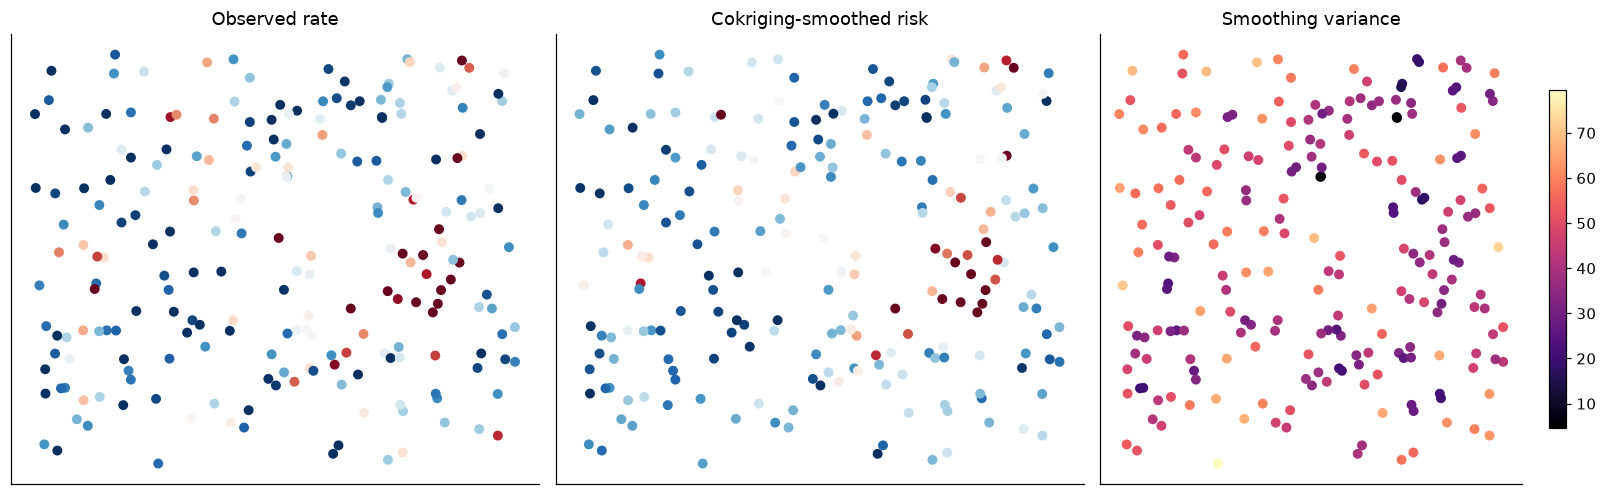

In [9]:
sm4 = {(a,b): shared_mean[(a,b)] for (a,b) in cross_pairs}
datasets = [dict(x=cent[:,0], y=cent[:,1], cases=counts[l], pop=pop) for l in range(P)]
smooth = mpk.poisson_cokrige(datasets, target, lmc, POP_RATE, sm4, smooth=True)

print(f"mean residual (bias)     = {np.nanmean(smooth['residual']):+.3f}")
print(f"MSPE vs observed         = {np.nanmean(smooth['residual']**2):.2f}")
print(f"MSPE vs TRUE latent risk = {np.nanmean((smooth['rate_pred']-rates_true[target])**2):.2f}"
      f"  (raw obs vs truth: {np.nanmean((rates_obs[target]-rates_true[target])**2):.2f})")
print(f"cor(smoothed, true risk) = {np.corrcoef(smooth['rate_pred'], rates_true[target])[0,1]:.3f}"
      f"  (raw obs: {np.corrcoef(rates_obs[target], rates_true[target])[0,1]:.3f})")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
vmin, vmax = np.percentile(rates_true[target], 5), np.percentile(rates_true[target], 95)
ax[0].scatter(cent[:,0], cent[:,1], c=rates_obs[target], s=30, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax[0].set_title("Observed rate")
ax[1].scatter(cent[:,0], cent[:,1], c=smooth["rate_pred"], s=30, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax[1].set_title("Cokriging-smoothed risk")
sv = ax[2].scatter(cent[:,0], cent[:,1], c=smooth["rate_var"], s=30, cmap="magma")
ax[2].set_title("Smoothing variance"); plt.colorbar(sv, ax=ax[2], shrink=.75)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

***
## 15. Application: Diabetes in the US Northeast

We now apply the method to **real county data** — diagnosed diabetes across the nine-state US Census **Northeast region** (New England + NJ, NY, PA; 217 counties). Diabetes is the Poisson target ($Y=$ `Diabetes_count`, $n=$ `POP_Total`); the two strongest correlated risk factors, **physical inactivity** and **obesity**, are the auxiliaries. Because they are reported as prevalence percentages over the *same* county population, we turn them into pseudo-counts $Y_l = \mathrm{round}(\text{pct}_l/100 \times n)$, so all three variables are co-located Poisson counts sharing the denominator $n$.

County boundaries and attributes are loaded from `data/diabetes_northeast.shp` (NAD 1983 Contiguous USA Albers / EPSG:5070) joined to `data/diabetes_northeast.csv`. Every map in this section is a **polygon choropleth** of the 217 counties.

Unlike the simulation, there is no known latent risk here, so — as in the paper's real-data analysis — hold-out predictions are scored against the **observed** diabetes rate.


In [10]:
# County polygons (NAD 1983 Contiguous USA Albers / EPSG:5070) + full attribute table.
# Shapefile sidecars: .shx, .dbf, .prj, .cpg. DBF truncates names, so join the CSV.
ne_poly = gpd.read_file("../data/diabetes_northeast.shp")
dia = pd.read_csv("../data/diabetes_northeast.csv")
ne_poly["FIPS"] = ne_poly["FIPS"].astype(int)
dia["FIPS"] = dia["FIPS"].astype(int)

ne = ne_poly[["FIPS", "geometry"]].merge(dia, on="FIPS", how="inner")
ne_gdf = ne

print(f"ne_gdf: {len(ne)} polygons from ../data/diabetes_northeast.shp | "
      f"{ne.geom_type.value_counts().to_dict()}")
print(f"CRS: {ne.crs}")

coordsD = np.column_stack([ne.X.values, ne.Y.values]) / 1000.0     # km
popD = ne.POP_Total.values.astype(float)
dia_names = ["Diabetes", "Physical Inactivity", "Obesity"]
yD = [ne.Diabetes_count.values.astype(float),
      np.round(ne.Physical_Inactivity.values / 100 * popD),
      np.round(ne.Obesity.values / 100 * popD)]
PD, targetD = 3, 0
ratesD = [yD[l] / popD * POP_RATE for l in range(PD)]
DD = np.sqrt(((coordsD[:, None, :] - coordsD[None, :, :]) ** 2).sum(-1))

print(f"{len(ne)} Northeast counties | diabetes rate/100k: "
      f"{ratesD[0].min():.0f}–{ratesD[0].max():.0f}")
print("rate correlation, diabetes vs [phys.inact., obesity]:",
      [round(np.corrcoef(ratesD[0], ratesD[k])[0, 1], 2) for k in (1, 2)])

def mapper(values, title, ax, cmap="RdBu_r", vmin=None, vmax=None, label=""):
    """Choropleth of county polygons (never a point scatter)."""
    gg = ne_gdf.merge(pd.DataFrame({"FIPS": ne.FIPS.values, "_v": values}), on="FIPS")
    gg.plot("_v", cmap=cmap, ax=ax, vmin=vmin, vmax=vmax, edgecolor="white",
            linewidth=.2, legend=True, legend_kwds={"shrink":.7, "label":label})
    ax.set_title(title); ax.set_axis_off()

ne


ne_gdf: 217 polygons from ../data/diabetes_northeast.shp | {'Polygon': 206, 'MultiPolygon': 11}
CRS: EPSG:5070
217 Northeast counties | diabetes rate/100k: 4873–10944
rate correlation, diabetes vs [phys.inact., obesity]: [np.float64(0.65), np.float64(0.68)]


,FIPS,geometry,State,County,X,Y,POP_Total,Diabetes_count,Diabetes_per,Obesity,Access_Excercise,Physical_Inactivity,PCP_rate,Food_Env_Index,SVI,Urban_Rural
0,9001,"POLYGON ((1841093.397 2228963.1, 1844972.639 2...",Connecticut,Fairfield County,1861863.825,2251708.214,944735.8,52448,6.42,21.48,96.6,17.34,93.8,8.5,0.6184,Urban
1,9003,"POLYGON ((1872705.891 2342970.068, 1883570.831...",Connecticut,Hartford County,1900269.968,2323058.093,892284.0,67168,8.58,27.66,96.6,20.20,95.2,8.0,0.5955,Urban
2,9005,"POLYGON ((1837787.573 2335808.573, 1848938.483...",Connecticut,Litchfield County,1859618.764,2311363.344,181160.4,12023,6.38,26.56,85.6,17.50,59.4,8.6,0.1512,Urban
3,9007,"POLYGON ((1907236.794 2301475.608, 1906653.117...",Connecticut,Middlesex County,1925466.445,2289801.725,162702.8,10215,6.32,26.42,94.8,17.06,73.8,8.4,0.1843,Urban
4,9009,"POLYGON ((1861276.383 2278707.821, 1867235.718...",Connecticut,New Haven County,1894969.234,2276090.852,856327.0,66825,8.84,29.64,95.4,20.78,88.2,7.9,0.6512,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,50019,"POLYGON ((1828968.025 2673572.59, 1832869.733 ...",Vermont,Orleans County,1855936.913,2659864.255,26909.0,2051,7.56,30.52,53.6,22.38,72.8,7.8,0.3129,Rural
213,50021,"POLYGON ((1796438.914 2508815.7, 1796491.77 25...",Vermont,Rutland County,1828543.331,2509418.815,58604.8,4714,7.94,32.06,81.2,19.76,77.6,8.1,0.3237,Urban
214,50023,"POLYGON ((1821538.746 2597981.661, 1823983.918...",Vermont,Washington County,1842580.514,2592608.186,58334.2,3541,6.38,23.88,78.4,14.76,104.2,8.3,0.1973,Urban
215,50025,"POLYGON ((1854199.52 2462122.166, 1852254.343 ...",Vermont,Windham County,1869695.705,2451839.421,42601.4,2663,6.04,23.72,69.0,15.54,102.6,8.0,0.3800,Rural


***
## 16. Diabetes and Its Risk Factors

The spatial patterns are strikingly concordant — Appalachian Pennsylvania and inland/northern counties carry higher diabetes, physical inactivity, and obesity together — which is exactly the cross-correlation cokriging exploits.


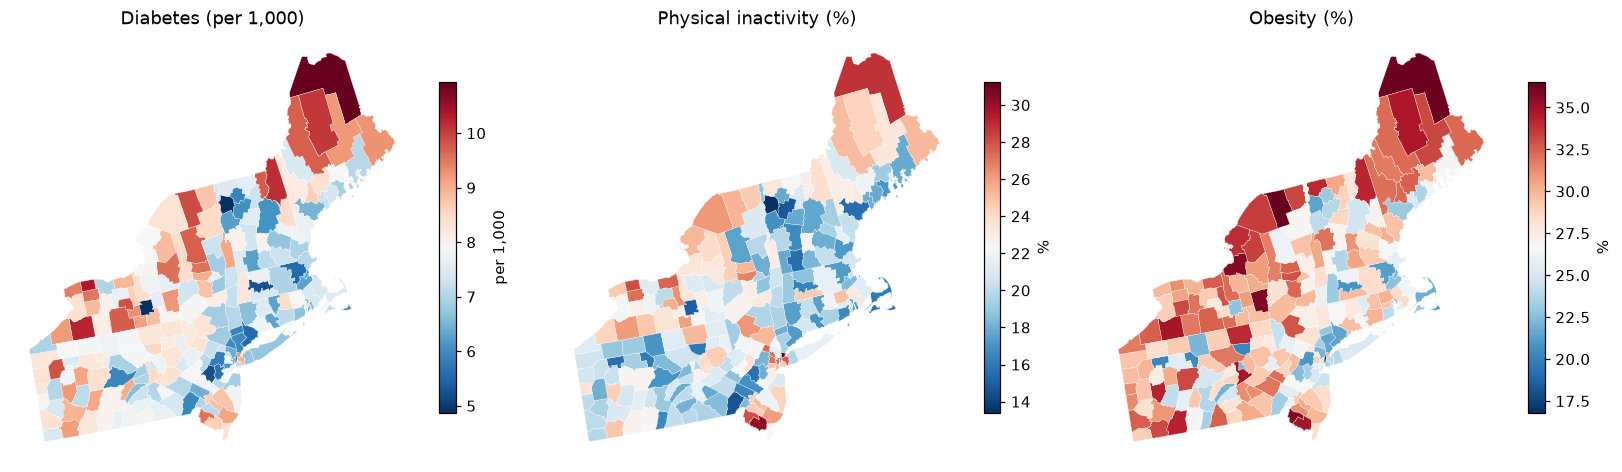

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for idx, (vals, title, cmap, label) in enumerate([
    (ratesD[0]/1000, "Diabetes (per 1,000)", "RdBu_r", "per 1,000"),
    (ne.Physical_Inactivity.values, "Physical inactivity (%)", "RdBu_r", "%"),
    (ne.Obesity.values, "Obesity (%)", "RdBu_r", "%")
]):
    mapper(vals, title, ax[idx], cmap, label=label)
plt.tight_layout()
plt.show()

***
## 17. Northeast Semivariograms and LMC


fitted LMC(model=Exp, range=38.1, P=3) | common range = 38 km


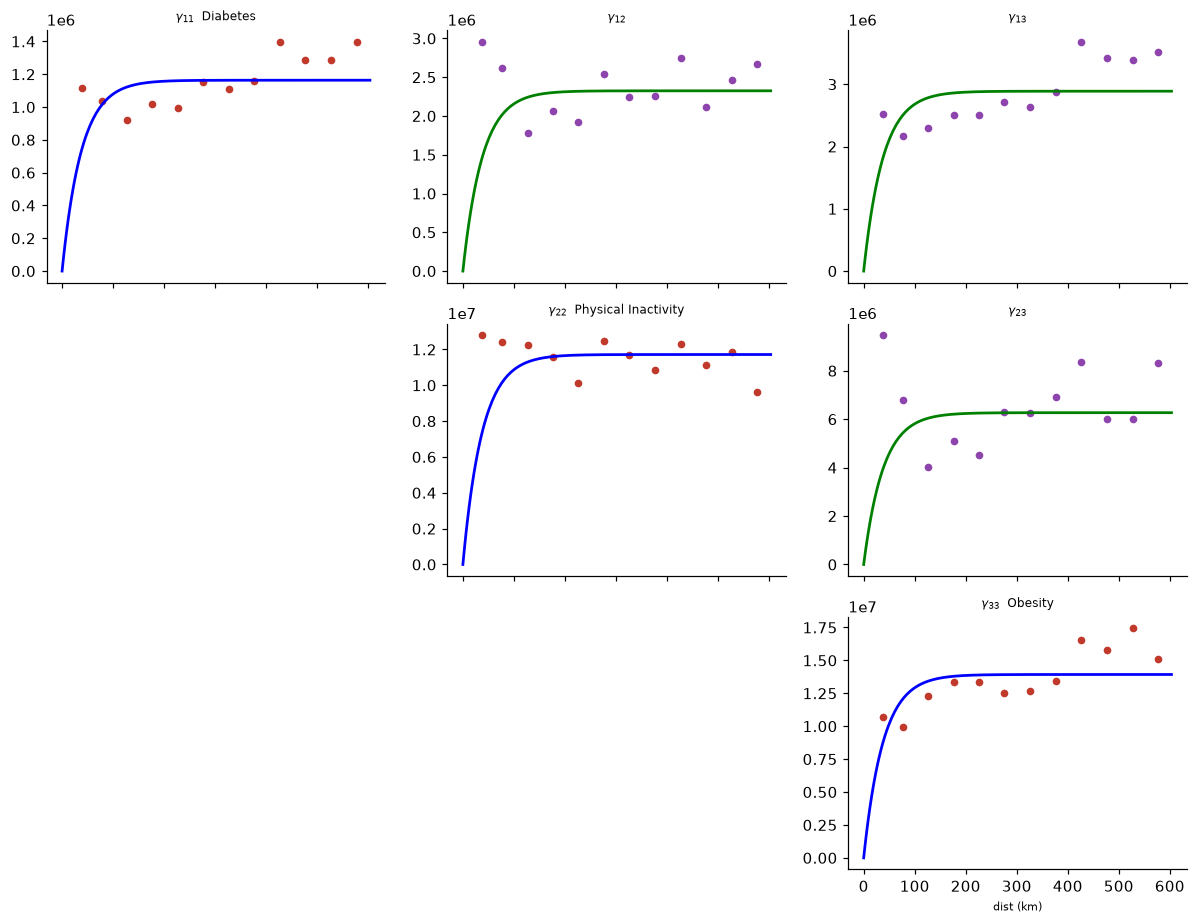

In [12]:
maxdD = DD.max() * 0.5
dvD = [mpk.pck_variogram(coordsD, yD[l], popD, POP_RATE, maxdD, 12) for l in range(PD)]
pairsD = [(l, k) for l in range(PD) for k in range(l+1, PD)]
rhoD, sharedD, cvD = {}, {}, []
for (l, k) in pairsD:
    r = max(np.corrcoef(ratesD[l], ratesD[k])[0, 1], 0.01)
    rr = mpk.shared_risk(ratesD[l], ratesD[k], r)
    rhoD[(l,k)] = r; sharedD[(l,k)] = float(np.mean(rr))
    cvD.append(mpk.pck_crossvariogram(coordsD, yD[l], yD[k], popD, rr, POP_RATE, maxdD, 12))

rngD = fit_exp(*dvD[targetD])[1]                       # range from target direct variogram
lmcD = mpk.fit_lmc(dvD, cvD, pairsD, PD, rng=rngD, model="Exp", fit_range=False)
print(f"fitted {lmcD} | common range = {lmcD.range:.0f} km")

fig, ax = plt.subplots(PD, PD, figsize=(11, 8.5), sharex=True)
hhD = np.linspace(0, maxdD, 200)
clook = {p: c for p, c in zip(pairsD, cvD)}
for l in range(PD):
    for k in range(PD):
        a = ax[l, k]
        if l == k:
            lags, gam, _ = dvD[l]
            a.plot(lags, gam, "o", ms=4, color="#c0392b")
            a.plot(hhD, lmcD.B[l,l]*(1-np.exp(-hhD/lmcD.range)), "b-", lw=1.8)
            a.set_title(f"$\\gamma_{{{l+1}{l+1}}}$  {dia_names[l]}", fontsize=8)
        elif k > l:
            lags, gam, _ = clook[(l, k)]
            a.plot(lags, gam, "o", ms=4, color="#8e44ad")
            a.plot(hhD, lmcD.B[l,k]*(1-np.exp(-hhD/lmcD.range)), "g-", lw=1.8)
            a.set_title(f"$\\gamma_{{{l+1}{k+1}}}$", fontsize=8)
        else:
            a.axis("off")
        if l == PD-1: a.set_xlabel("dist (km)", fontsize=7)
plt.tight_layout(); plt.show()

***
## 18. Predicting Held-Out Diabetes Rates

30% of counties are held out and predicted from the rest with univariate Poisson kriging and with bi/tri-variate cokriging that adds the risk factors.


In [13]:
nhD = int(0.30 * len(ne))
holdD = np.sort(RNG.choice(len(ne), nhD, replace=False))
maskD = np.ones(len(ne), bool); maskD[holdD] = False
truthD = ratesD[0][holdD]                              # observed held-out rate

spD, rpD = fit_exp(*mpk.pck_variogram(coordsD[maskD], yD[0][maskD], popD[maskD],
                                      POP_RATE, maxdD, 12))
pkD = mpk.poisson_krige(dict(x=coordsD[maskD,0], y=coordsD[maskD,1],
                             cases=yD[0][maskD], pop=popD[maskD]),
                        sill=spD, rng=rpD, model="Exp", pop_rate=POP_RATE,
                        coords_pred=coordsD[holdD])

def setsD(vs):
    ds = []
    for l in vs:
        if l == 0: ds.append(dict(x=coordsD[maskD,0], y=coordsD[maskD,1],
                                  cases=yD[l][maskD], pop=popD[maskD]))
        else:      ds.append(dict(x=coordsD[:,0], y=coordsD[:,1], cases=yD[l], pop=popD))
    return ds

def metD(p, lab):
    e = p - truthD
    return dict(method=lab, MSPE=np.mean(e**2), MAE=np.mean(np.abs(e)),
                cor=np.corrcoef(p, truthD)[0,1])

rowsD = [dict(**metD(pkD["pred"], "PK (univariate)"), mean_var=pkD["var"].mean())]
predsD = {"PK (univariate)": pkD["pred"]}
for lab, vs in [("PCK + Phys.Inact.", [0,1]), ("PCK + Phys.Inact. + Obesity", [0,1,2])]:
    sm = {}
    for a in range(len(vs)):
        for b in range(a+1, len(vs)):
            la, lb = vs[a], vs[b]
            sm[(a,b)] = sharedD[(la,lb) if (la,lb) in sharedD else (lb,la)]
    sub = mpk.LMC(lmcD.B[np.ix_(vs, vs)], lmcD.range, lmcD.model)
    res = mpk.poisson_cokrige(setsD(vs), 0, sub, POP_RATE, sm, coords_pred=coordsD[holdD])
    rowsD.append(dict(**metD(res["pred"], lab), mean_var=res["var"].mean()))
    predsD[lab] = res["pred"]

baseD = rowsD[0]["MSPE"]
tblD = pd.DataFrame(rowsD).set_index("method")
tblD["MSPE drop %"] = (100*(baseD - tblD["MSPE"])/baseD).round(0)
tblD.round(2)

,MSPE,MAE,cor,mean_var,MSPE drop %
method,,,,,
PK (univariate),960133.17,785.04,0.52,453978.84,0.0
PCK + Phys.Inact.,487320.15,581.53,0.81,508846.86,49.0
PCK + Phys.Inact. + Obesity,517042.25,587.65,0.81,323485.09,46.0


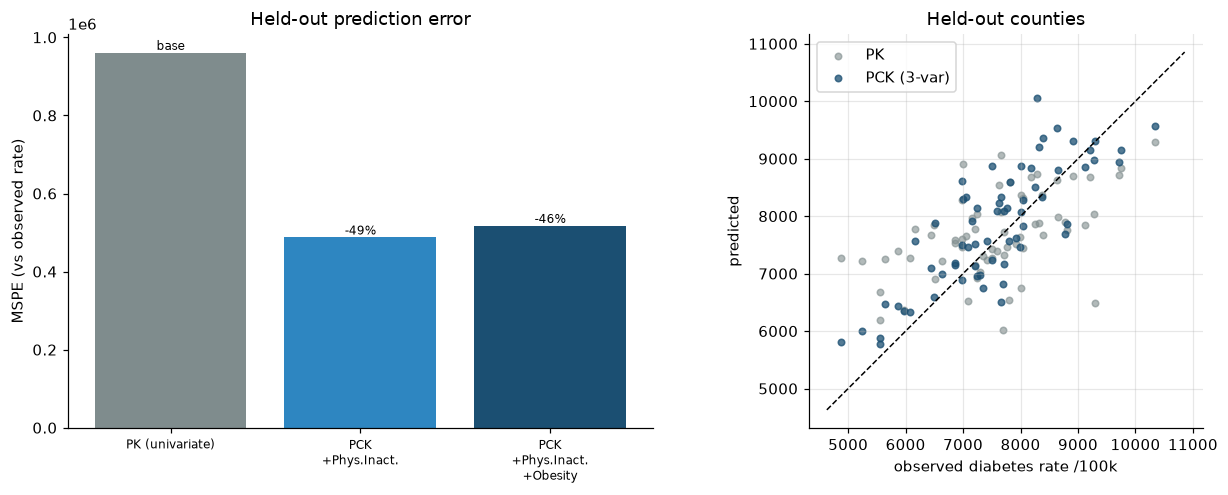

Best: PCK + Phys.Inact. -> MSPE reduced 49% vs univariate PK; correlation 0.52 -> 0.81.


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
labsD = list(predsD); colsD = ["#7f8c8d", "#2e86c1", "#1b4f72"]
ax[0].bar(range(len(rowsD)), [r["MSPE"] for r in rowsD], color=colsD)
ax[0].set_xticks(range(len(rowsD)))
ax[0].set_xticklabels([l.replace(" + ", "\n+") for l in labsD], fontsize=8)
ax[0].set_ylabel("MSPE (vs observed rate)"); ax[0].set_title("Held-out prediction error")
for i, r in enumerate(rowsD):
    ax[0].text(i, r["MSPE"], "base" if i == 0 else f'-{100*(baseD-r["MSPE"])/baseD:.0f}%',
               ha="center", va="bottom", fontsize=8)
lim = [truthD.min()*0.95, truthD.max()*1.05]
ax[1].plot(lim, lim, "k--", lw=1)
ax[1].scatter(truthD, predsD["PK (univariate)"], s=18, alpha=.6, color="#7f8c8d", label="PK")
ax[1].scatter(truthD, predsD[labsD[-1]], s=18, alpha=.75, color="#1b4f72", label="PCK (3-var)")
ax[1].set_xlabel("observed diabetes rate /100k"); ax[1].set_ylabel("predicted")
ax[1].set_aspect("equal"); ax[1].set_title("Held-out counties"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

bestD = min(rowsD[1:], key=lambda r: r["MSPE"])
print(f"Best: {bestD['method']} -> MSPE reduced {100*(baseD-bestD['MSPE'])/baseD:.0f}% "
      f"vs univariate PK; correlation {rowsD[0]['cor']:.2f} -> {bestD['cor']:.2f}.")

***
## 19. Smoothed Diabetes Risk Map

Leave-one-out cokriging smoothing filters the county-level Poisson noise using both risk factors, giving a cleaner risk surface and its uncertainty.


mean residual (bias) = +1.8 per 100k | smoothing MSPE = 586045 | cor(smoothed, observed) = 0.746


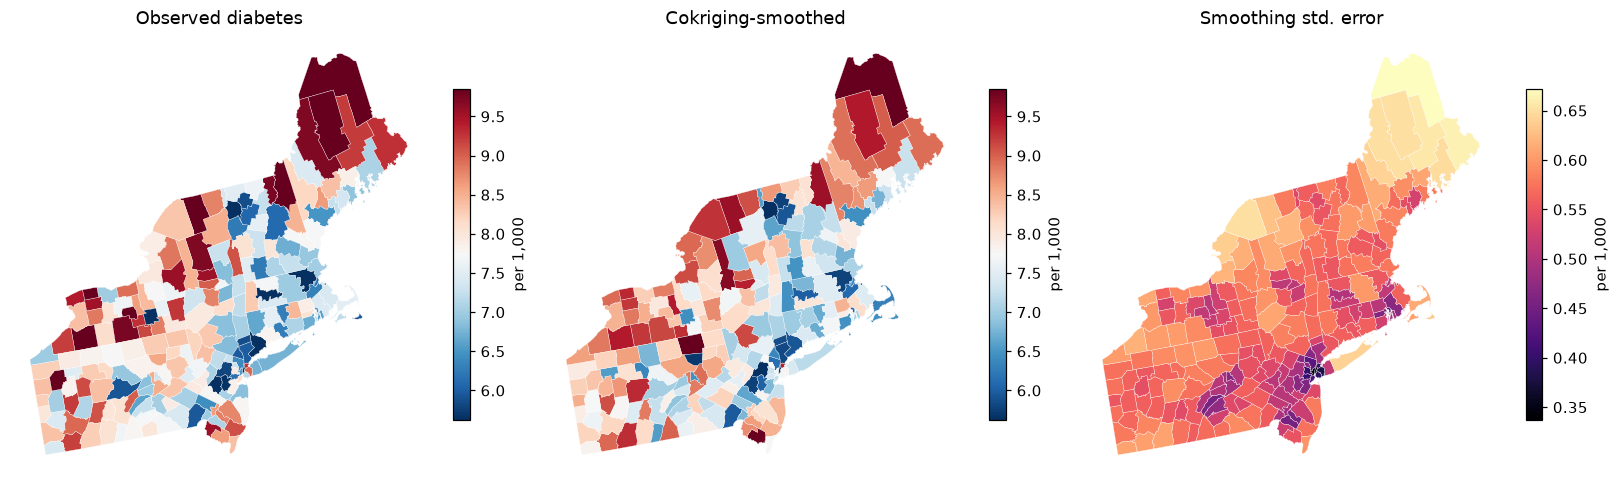

In [15]:
smD = {(l, k): sharedD[(l, k)] for (l, k) in pairsD}
dsetsD = [dict(x=coordsD[:,0], y=coordsD[:,1], cases=yD[l], pop=popD) for l in range(PD)]
smoothD = mpk.poisson_cokrige(dsetsD, targetD, lmcD, POP_RATE, smD, smooth=True)
print(f"mean residual (bias) = {np.nanmean(smoothD['residual']):+.1f} per 100k "
      f"| smoothing MSPE = {np.nanmean(smoothD['residual']**2):.0f} "
      f"| cor(smoothed, observed) = "
      f"{np.corrcoef(smoothD['rate_pred'], smoothD['observed'])[0,1]:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
vlo, vhi = np.percentile(ratesD[0]/1000, 3), np.percentile(ratesD[0]/1000, 97)
mapper(ratesD[0]/1000, "Observed diabetes", ax[0], "RdBu_r", vlo, vhi, "per 1,000")
mapper(smoothD["rate_pred"]/1000, "Cokriging-smoothed", ax[1], "RdBu_r", vlo, vhi, "per 1,000")
mapper(np.sqrt(smoothD["rate_var"])/1000, "Smoothing std. error", ax[2], "magma", label="per 1,000")
plt.tight_layout(); plt.show()

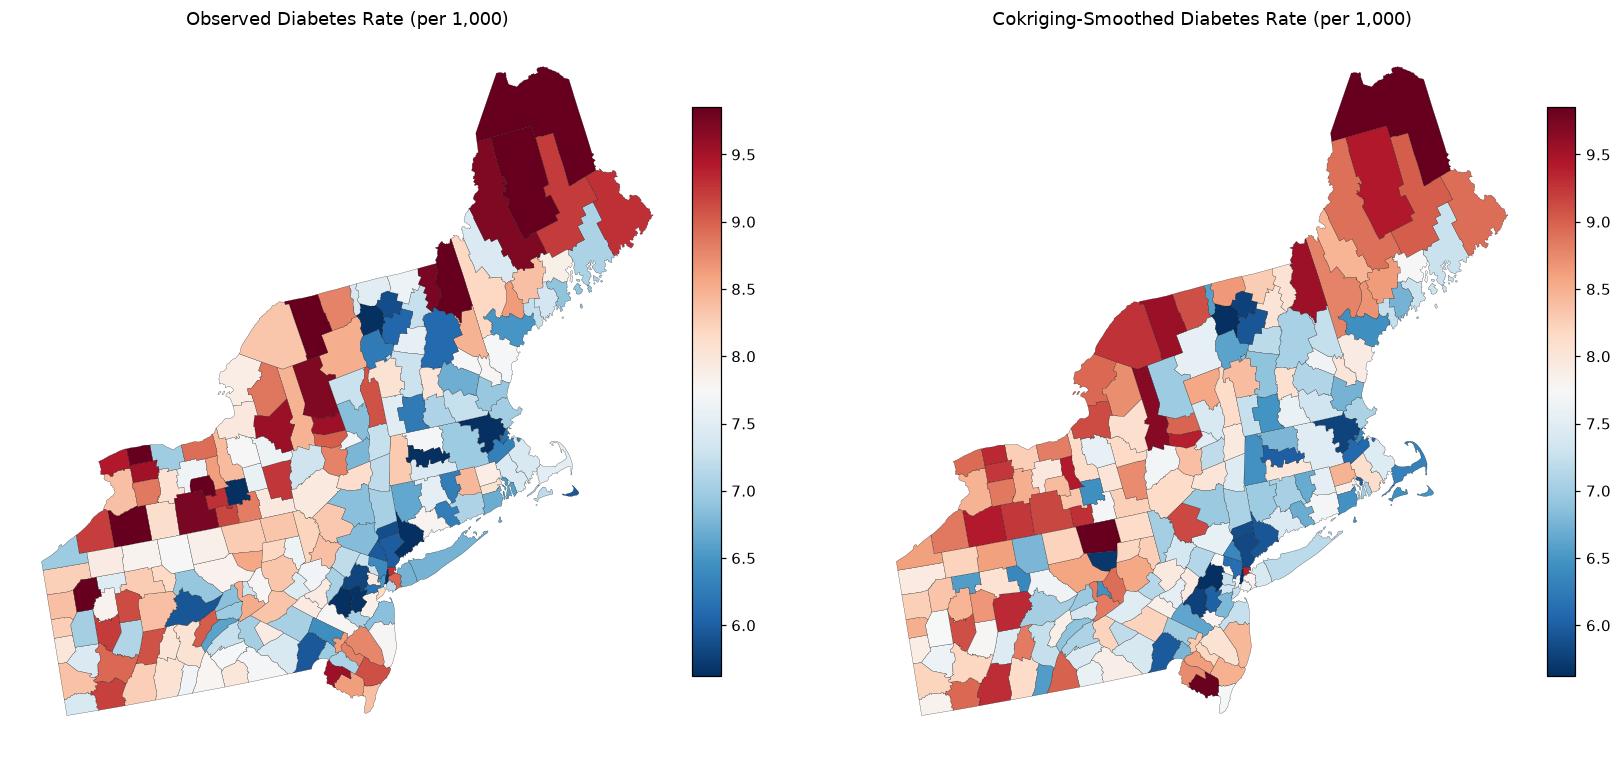

In [16]:
# Polygon choropleths of observed vs cokriging-smoothed diabetes rates
gg = ne_gdf.merge(
    pd.DataFrame({
        "FIPS": ne.FIPS.values,
        "obs": ratesD[0] / 1000,
        "cokriged": smoothD["rate_pred"] / 1000,
    }),
    on="FIPS",
)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
vlo, vhi = np.percentile(gg["obs"].dropna(), 3), np.percentile(gg["obs"].dropna(), 97)
norm = Normalize(vmin=vlo, vmax=vhi)
cmap = "RdBu_r"
smap = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

gg.plot("obs", ax=axes[0], cmap=cmap, norm=norm, edgecolor="k", linewidth=0.15)
axes[0].set_title("Observed Diabetes Rate (per 1,000)")
axes[0].axis("off")
fig.colorbar(smap, ax=axes[0], orientation="vertical", fraction=0.034, pad=0.01)

gg.plot("cokriged", ax=axes[1], cmap=cmap, norm=norm, edgecolor="k", linewidth=0.15)
axes[1].set_title("Cokriging-Smoothed Diabetes Rate (per 1,000)")
axes[1].axis("off")
fig.colorbar(smap, ax=axes[1], orientation="vertical", fraction=0.034, pad=0.01)
plt.tight_layout()
plt.show()


***
## 20. CPU vs GPU Poisson Cokriging Timing

The 217-county Northeast application is too small for a GPU comparison: the batched
cokriging solve is a stack of modest $(P k + P)\times(P k + P)$ systems, and
host→device copies dominate. Here we time **k-nearest-neighbor** Poisson cokriging
(`poisson_cokrige`, `number_of_neighbors=k`) on **CPU** (`use_gpu=False`) versus
**GPU** (`use_gpu=True`) using **USA county diabetes prevalence** with the same two
auxiliaries as §15–19.

Data:

1. Join `data/usa_diabetes_data.csv` (3,107 counties) to `data/US_COUNTY.shp` on
   `FIPS`. Coordinates are NAD 1983 Albers metres (same CRS as the polygons).
2. Target cases are `Diabetes_count`; physical inactivity and obesity percentages
   are converted to pseudo-counts (`pct/100 × POP_Total`), as in the Northeast
   application. `pop_rate=100000`.
3. Fit one exponential LMC on the 3,107 centroids (fitting $\gamma$ / $B$ is
   **not** in the times). Draw a separate prediction set in the county bounding box.

Unlike global cokriging, the k-NN GPU work scales with **$n_{\mathrm{pred}}$**
(one stacked solve of shape `(n_pred, P k + P, P k + P)`), not $(N P)^3$.
Training size is therefore held at 3,107 and we vary $n_{\mathrm{pred}}$.
Neighborhood size is $k=16$; $P=3$ (diabetes + inactivity + obesity).

Each timing is the **median** of three `poisson_cokrige` calls after a short GPU
warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel
here, the GPU column is skipped. Global cokriging and LOO smoothing are not
timed: those paths are not a fixed-$k$ stack.


USA county diabetes (k-NN Poisson cokriging)
  counties   : 3,107 joined on FIPS (usa_diabetes_data.csv + US_COUNTY.shp)
  variables  : Diabetes (target) + Physical inactivity + Obesity
  diabetes   : 24029398 counts; rate/100k [3270, 2712283]
  LMC        : LMC(model=Exp, range=1.36e+06, P=3); B diagonal [46498147.1 29339737.3 33466325.6]
  CRS        : NAD 1983 Albers (metres)

GPU usable : True
Repeats    : 3  (median wall time of poisson_cokrige, k-NN)
n_train    : 3107  (USA diabetes counties)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the US_COUNTY bbox)
neighbors  : 16; P=3; pop_rate=100000

     dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
USA diabetes     3107     500      27.5      10.9   2.54×   True
USA diabetes     3107    1000      57.8      14.9   3.87×   True
USA diabetes     3107    2000     116.7      24.9   4.69×   True
USA diabetes     3107    4000     244.5      46.5   5.26×   True
USA diabetes     3107    8000     508.0      79

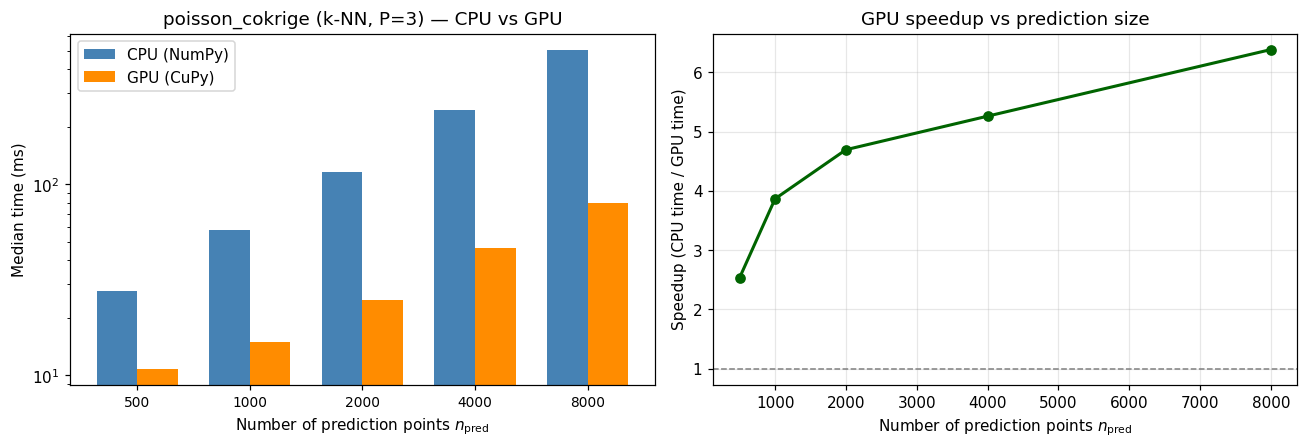

In [24]:
import time

N_REPEATS = 3
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
K = 16

df_dm = pd.read_csv("../data/usa_diabetes_data.csv")
gdf_cty = gpd.read_file("../data/US_COUNTY.shp")
df_dm["FIPS"] = df_dm["FIPS"].astype(int)
gdf_cty["FIPS"] = gdf_cty["FIPS"].astype(int)
joined = gdf_cty.merge(df_dm, on="FIPS", how="inner")
joined = joined.dropna(subset=["Diabetes_count", "POP_Total",
                               "Physical_Inactivity", "Obesity", "X", "Y"])
joined = joined[joined["POP_Total"] > 0].copy()

xy_train = joined[["X", "Y"]].to_numpy(dtype=float)
pop_u = joined["POP_Total"].to_numpy(dtype=float)
y_dia = joined["Diabetes_count"].to_numpy(dtype=float)
y_inact = np.round(joined["Physical_Inactivity"].to_numpy(dtype=float) / 100.0 * pop_u)
y_obes = np.round(joined["Obesity"].to_numpy(dtype=float) / 100.0 * pop_u)
n_train = len(xy_train)

dsets_u = [
    dict(x=xy_train[:, 0], y=xy_train[:, 1], cases=y_dia, pop=pop_u),
    dict(x=xy_train[:, 0], y=xy_train[:, 1], cases=y_inact, pop=pop_u),
    dict(x=xy_train[:, 0], y=xy_train[:, 1], cases=y_obes, pop=pop_u),
]
P_u = 3
rates_u = [dsets_u[l]["cases"] / pop_u * POP_RATE for l in range(P_u)]

xmin, ymin, xmax, ymax = joined.total_bounds
rng_sim = np.random.default_rng(42)
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

maxd_u = 0.5 * np.hypot(xmax - xmin, ymax - ymin)
direct_u = [
    mpk.pck_variogram(xy_train, dsets_u[l]["cases"], pop_u, POP_RATE, maxd_u, 12)
    for l in range(P_u)
]
pairs_u, shared_u, cross_u = [], {}, []
for l in range(P_u):
    for kk in range(l + 1, P_u):
        rho = np.corrcoef(rates_u[l], rates_u[kk])[0, 1]
        rlk = mpk.shared_risk(rates_u[l], rates_u[kk], rho)
        pairs_u.append((l, kk))
        shared_u[(l, kk)] = float(np.mean(rlk))
        cross_u.append(mpk.pck_crossvariogram(
            xy_train, dsets_u[l]["cases"], dsets_u[kk]["cases"], pop_u, rlk,
            POP_RATE, maxd_u, 12,
        ))
rng0 = 0.25 * np.hypot(xmax - xmin, ymax - ymin)
lmc_u = mpk.fit_lmc(direct_u, cross_u, pairs_u, P_u, rng0, model="Exp")

print("USA county diabetes (k-NN Poisson cokriging)")
print(f"  counties   : {n_train:,} joined on FIPS (usa_diabetes_data.csv + US_COUNTY.shp)")
print("  variables  : Diabetes (target) + Physical inactivity + Obesity")
print(f"  diabetes   : {y_dia.sum():.0f} counts; rate/100k "
      f"[{rates_u[0].min():.0f}, {rates_u[0].max():.0f}]")
print(f"  LMC        : {lmc_u}; B diagonal {np.diag(lmc_u.B).round(1)}")
print("  CRS        : NAD 1983 Albers (metres)")
print()


def _time_pck(xy_pr, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of poisson_cokrige (k-NN)."""
    kw = dict(
        datasets=dsets_u, target=0, lmc=lmc_u, pop_rate=POP_RATE,
        shared_mean=shared_u, number_of_neighbors=K, use_gpu=use_gpu,
    )
    if warmup:
        k_pr = min(40, len(xy_pr))
        mpk.poisson_cokrige(**kw, coords_pred=xy_pred_all[:k_pr])
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last = mpk.poisson_cokrige(**kw, coords_pred=xy_pr)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of poisson_cokrige, k-NN)")
print(f"n_train    : {n_train}  (USA diabetes counties)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the US_COUNTY bbox)")
print(f"neighbors  : {K}; P=3; pop_rate={POP_RATE:.0f}")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, pred_cpu = _time_pck(xy_pr, use_gpu=False)
    row = {
        "dataset": "USA diabetes",
        "n_train": n_train,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_pck(xy_pr, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = bool(
            np.allclose(pred_cpu["pred"], pred_gpu["pred"], rtol=1e-4, atol=1e-4)
            and np.allclose(pred_cpu["var"], pred_gpu["var"], rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("poisson_cokrige (k-NN, P=3) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and kriging variances from the two backends should **match** (`match = True`). The GPU speedup comes from the batched $(n_{\mathrm{pred}}, P k + P, P k + P)$ Poisson-cokriging solve, not from the county join or the LMC fit (those run once on CPU and are excluded from the times). Small $n_{\mathrm{pred}}$ can show little GPU gain because kernel-launch overhead dominates; as the prediction set grows the stacked solve keeps the GPU several times faster. Use `use_gpu=USE_GPU` with `number_of_neighbors=k` so the same cells run on a laptop CPU or a CUDA workstation without edits. Global cokriging and LOO smoothing stay on CPU.


***
## 21. Summary and Conclusions

- **Multivariate Poisson cokriging** predicts a target disease risk by treating counts as Poisson and borrowing strength from correlated auxiliaries through an LMC.
- **`pygstat.multi_poisson_kriging`** implements the population-weighted (cross-)semivariograms, a valid LMC, and the cokriging system with Poisson reliability terms on the block diagonal.
- *Simulation:* adding correlated auxiliary diseases **cuts the MSPE** of the target-risk prediction and raises the correlation with the true risk; the prediction variance drops once auxiliaries enter.
- *Northeast diabetes:* using physical inactivity and obesity as auxiliaries **reduces held-out prediction MSPE** versus univariate Poisson kriging and improves agreement with observed rates.
- Leave-one-out **smoothing** filters county-level Poisson noise with near-zero bias, yielding a cleaner diabetes risk surface.
- **CPU / GPU.** k-NN Poisson cokriging (`poisson_cokrige`, `number_of_neighbors=k`, `use_gpu=USE_GPU`) was timed on **USA county diabetes** (3,107 counties joined to `US_COUNTY.shp`, $P=3$). The GPU batched `(n_pred, P k + P, P k + P)` solve is the accelerated step; the global system and LOO smoothing stay on CPU.

| Object | Role in this notebook |
|---|---|
| `pck_variogram` / `pck_crossvariogram` | population-weighted (cross-)semivariograms |
| `fit_lmc` / `LMC` | valid Linear Model of Coregionalization |
| `poisson_cokrige` | $N$-variate Poisson cokriging; `use_gpu` for batched k-NN `predict` |
| `poisson_krige` | univariate Poisson kriging baseline |


***
## 22. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Wackernagel, H. (2003). *Multivariate Geostatistics* (3rd ed.). Springer. | Linear Model of Coregionalization |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Cokriging, LMC, change of support |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Multivariate covariance models |

### Key papers

| Paper | Contribution |
|---|---|
| Payares-Garcia, D., Osei, F., Mateu, J. & Stein, A. (2024). Multivariate Poisson cokriging: a geostatistical model for health count data. *Statistical Methods in Medical Research* 33(10), 1637–1656. | Method implemented here |
| Payares-Garcia, D. et al. (2023). Bivariate Poisson cokriging. *Spatial Statistics*. | Bivariate precursor |
| Goovaerts, P. (2006). Geostatistical analysis of disease data. *Int. J. Health Geographics* 5:52. | Univariate Poisson kriging |

### In this library

| Object | Role |
|---|---|
| `pygstat.multi_poisson_kriging.poisson_cokrige` | $N$-variate Poisson cokriging (`use_gpu` + `number_of_neighbors` for batched k-NN) |
| `pygstat.multi_poisson_kriging.poisson_krige` | univariate Poisson kriging |
| `pygstat.multi_poisson_kriging.fit_lmc` | LMC fit with PSD projection |
| `pygstat.PoissonKriging` | centroid Poisson kriging (Tutorial 13.1) |
